# Finding/opening ACCESS-OM3 `MC_25km_jra_ryf-1.0-beta` test run output using intake

This notebook demonstrates how to using intake-esm to find and load data data from the ACCESS-OM3 `MC_25km_jra_ryf-1.0-beta` test run.

For more information about using intake-esm to find and load data, see:
- the [intake-esm documentation](https://intake-esm.readthedocs.io/en/stable/)
- [this section](https://access-nri-intake-catalog.readthedocs.io/en/latest/usage/quickstart.html#using-an-intake-esm-datastore) of the access-nri-intake-catalog documentation

In [25]:
#The following cell must be in all notebooks!
#It allows us to run all the notebooks at once, note that the following cell has a tag "parameters" which allows us to pass in arguments externally using papermill (see mkfigs.sh for details)

In [26]:
import warnings
import os
warnings.simplefilter(action='ignore')
os.environ["PYTHONWARNINGS"] = "ignore"

In [27]:
#parameters

### USER EDIT start
esm_file='/g/data/zv30/non-cmip/ACCESS-CM3/cm3-run-11-08-2025-25km-beta-om3-new-um-params/cm3-demo-datastore/cm3-demo-datastore.json'
plotfolder='/g/data/tm70/ek4684/access-om3-paper-1/notebooks/mkfigs_output4/'
dpi=300
### USER EDIT stop

import matplotlib as mpl
import os
%matplotlib inline
mpl.rcParams['figure.dpi']= dpi

os.makedirs(plotfolder, exist_ok=True)

 # a similar cell under this means it's being run in batch
print("ESM datastore path: ",esm_file)
print("Plot folder path: ",plotfolder)

ESM datastore path:  /g/data/zv30/non-cmip/ACCESS-CM3/cm3-run-11-08-2025-25km-beta-om3-new-um-params/cm3-demo-datastore/cm3-demo-datastore.json
Plot folder path:  /g/data/tm70/ek4684/access-om3-paper-1/notebooks/mkfigs_output4/


In [28]:
import xarray as xr
import cf_xarray as cfxr
import intake
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
from distributed import Client
import numpy as np

In [29]:
client = Client(threads_per_worker=1)
print(client.dashboard_link)

/proxy/39875/status


### Open the intake-esm datastore

In [30]:
#datastore_path = "/g/data/ol01/access-om3-output/access-om3-025/MC_25km_jra_ryf-1.0-beta/experiment_datastore.json"
COLUMNS_WITH_ITERABLES = [
        "variable",
        "variable_long_name",
        "variable_standard_name",
        "variable_cell_methods",
        "variable_units"
]

datastore = intake.open_esm_datastore(
    esm_file,
    columns_with_iterables=COLUMNS_WITH_ITERABLES
)


### What ocean variables are available at monthly frequency?

In [6]:
def available_variables(datastore):
    """Return a pandas dataframe summarising the variables in a datastore"""
    variable_columns = [col for col in datastore.df.columns if "variable" in col]
    return (
        datastore.df[variable_columns]
        .explode(variable_columns)
        .drop_duplicates()
        .set_index("variable")
        .sort_index()
    )

In [7]:
datastore_filtered = datastore.search(realm="ocean", frequency="1mon")

for col in COLUMNS_WITH_ITERABLES:
    datastore_filtered.df[col] = datastore_filtered.df[col].astype("object").map(lambda x: list(map(str, x)))

available_variables(datastore_filtered)

,variable_long_name,variable_standard_name,variable_cell_methods,variable_units
variable,,,,
Heat_PmE,Heat flux into ocean from mass flux into ocean,,area:mean yh:mean xh:mean time: mean,W m-2
KE,Layer kinetic energy per unit mass,,area:mean zl:mean yh:mean xh:mean time: mean,m2 s-2
Rd_dx,Ratio between deformation radius and grid spacing,,area:mean yh:mean xh:mean time: mean,m m-1
SSH,Sea Surface Height,,area:mean yh:mean xh:mean time: mean,m
SSU,Sea Surface Zonal Velocity,,yh:mean xq:point time: mean,m s-1
...,...,...,...,...
yh,h point nominal latitude,,,degrees_north
yq,q point nominal latitude,,,degrees_north
z_l,Depth at cell center,,,meters


### Load monthly sea surface salinity (`sos`)from CM2 and CM3

In [8]:
%%time
cm3_sss = datastore.search(variable="sos", frequency="1mon").to_dask(
    xarray_open_kwargs = dict(
        chunks={"yh": -1, "xh": -1}, # Good for spatial operations, but not temporal
        decode_timedelta=True
    )
).sos

CPU times: user 3.35 s, sys: 464 ms, total: 3.81 s
Wall time: 28.3 s


In [9]:
cm2_sss = []

for year in range(1, 51):
    for month in [1, 7]:
        
        fn = f'ocean-2d-surface_salt-1-monthly-mean-ym_{str(year).zfill(4)}_0{month}.nc'
        fp = f'/g/data/p73/archive/non-CMIP/ACCESS-CM2/cj877/history/ocn/{fn}'
        cm2_sss.append(xr.open_dataset(fp, drop_variables=['average_T1', 'average_T2'], chunks='auto').surface_salt)

cm2_sss = xr.concat(cm2_sss, dim='time').rename(dict(xt_ocean='xh', yt_ocean='yh'))

In [10]:
def construct_lon_lat(xh, yh, target_lon, target_lat):
    def find_indices(xh, yh, target_lon, target_lat):
        if hasattr(xh, "values"):
            xh = xh.values
        if hasattr(yh, "values"):
            yh = yh.values
    
        lon_diff = np.abs(xh - target_lon)
        lat_diff = np.abs(yh - target_lat)
    
        nearest_lon_idx = np.argmin(lon_diff)
        nearest_lat_idx = np.argmin(lat_diff)
        return (
            xh[nearest_lon_idx],
            yh[nearest_lat_idx],
        )

    lon = []
    lat = []
    for i in range(len(target_lon)):
        lon_tmp, lat_tmp = find_indices(xh, yh, target_lon[i], target_lat[i])
        lon.append(lon_tmp)
        lat.append(lat_tmp)

    return lon, lat

## Create basin extents

In [15]:
seas = [
    "Baltic Sea",
    "Med Sea",
    "Red Sea",
    "Persian Gulf",
    "White Sea",
    "Gulf of Carpentaria"
]

def _add_basin(target_lon, target_lat):
    lon, lat = construct_lon_lat(xh, yh, target_lon, target_lat)
    lon_lat_pairs_all["om3"].append(([lon[0], lon[1]], [lat[0], lat[1]]))
    
    lon, lat = construct_lon_lat(xt, yt, target_lon, target_lat)
    lon_lat_pairs_all["om2"].append(([lon[0], lon[1]], [lat[0], lat[1]]))


lon_lat_pairs_all = {
    "om3": [],
    "om2": [],
}
                 
# OM3
xh = cm3_sss.xh
yh = cm3_sss.yh

xt = cm2_sss.xh
yt = cm2_sss.yh

# Baltic Sea
target_lon = [13, 30]
target_lat = [53, 58]
_add_basin(target_lon, target_lat)


# Med Sea
target_lon = [0, 35]
target_lat = [31, 41]
_add_basin(target_lon, target_lat)

# Red Sea
target_lon = [33, 44]
target_lat = [12, 29]
_add_basin(target_lon, target_lat)

# Persian Gulf
target_lon = [47, 56]
target_lat = [24, 31]
_add_basin(target_lon, target_lat)

# White Sea
target_lon = [31, 41]
target_lat = [63, 68]
_add_basin(target_lon, target_lat)

# Gulf of Carpentaria
target_lon = [-228, -218]
target_lat = [-20, -13]
_add_basin(target_lon, target_lat)

In [12]:
def subplots_fig_ax(num_plots, ncols, figsize):
    if num_plots>1:
        nrows = (num_plots + ncols - 1) // ncols
        fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize)
        axes = axes.flatten() if (nrows * ncols > 1) else [axes]
    else:
        fig, axes = plt.subplots(figsize=figsize)
    return fig, axes

## Calculate salinity aggregates

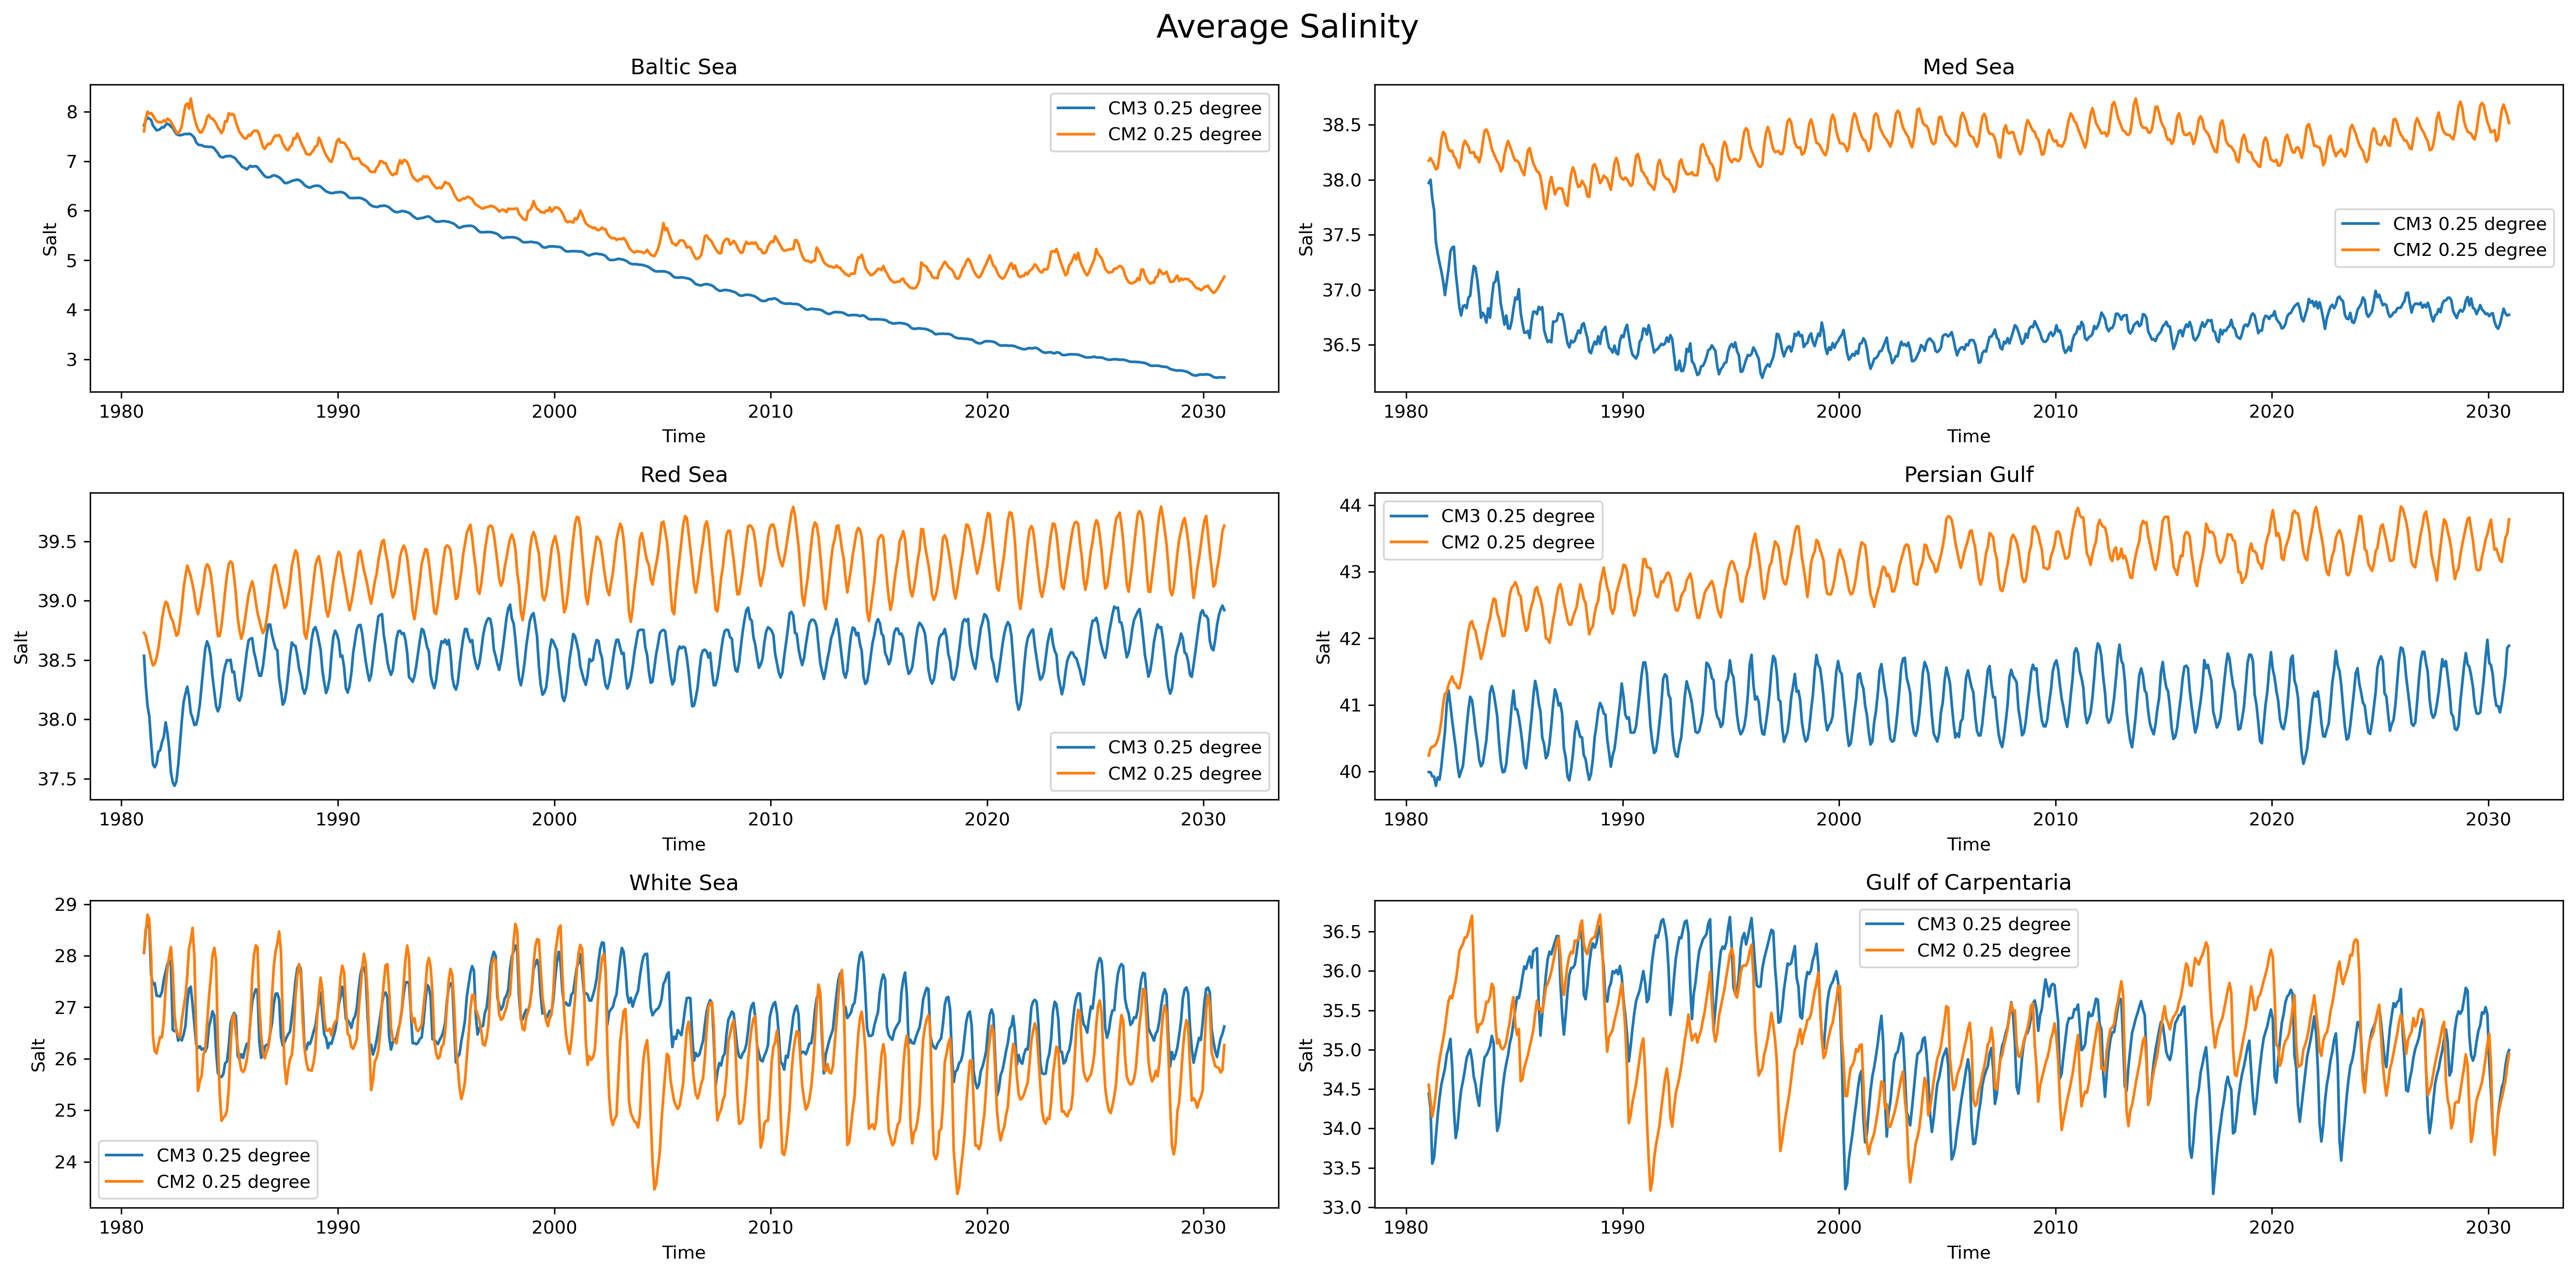

In [23]:
figsize = (20, 10)
num_plots = len(lon_lat_pairs_all["om3"])
ncols = 2
fig, axes = subplots_fig_ax(num_plots, ncols, figsize)

axes = axes.flatten()

for pair_idx, (lon, lat) in enumerate(lon_lat_pairs_all["om3"]):
    ax = axes[pair_idx]
    cm3_avg_sal = cm3_sss.sel(xh=slice(lon[0], lon[1]), yh=slice(lat[0], lat[1])).mean(dim=("xh", "yh")).compute()
    cm3_avg_sal.plot(ax=ax, label='CM3 0.25 degree')


n_time = min(len(cm3_sss.time), len(cm3_sss.time))
time_ax = cm3_sss.time
for pair_idx, (lon, lat) in enumerate(lon_lat_pairs_all["om2"]):
    ax = axes[pair_idx]
    cm2_avg_sal = cm2_sss.sel(xh=slice(lon[0], lon[1]), yh=slice(lat[0], lat[1])).mean(dim=("xh", "yh")).compute()
    ax.plot(time_ax[:n_time], cm2_avg_sal[:n_time], label='CM2 0.25 degree')

    ax.set_title(f"{seas[pair_idx]}")
    ax.set_xlabel("Time")
    ax.set_ylabel("Salt")
    ax.legend(loc="best")
        

for j in range(num_plots, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Average Salinity", fontsize=18)
plt.tight_layout()

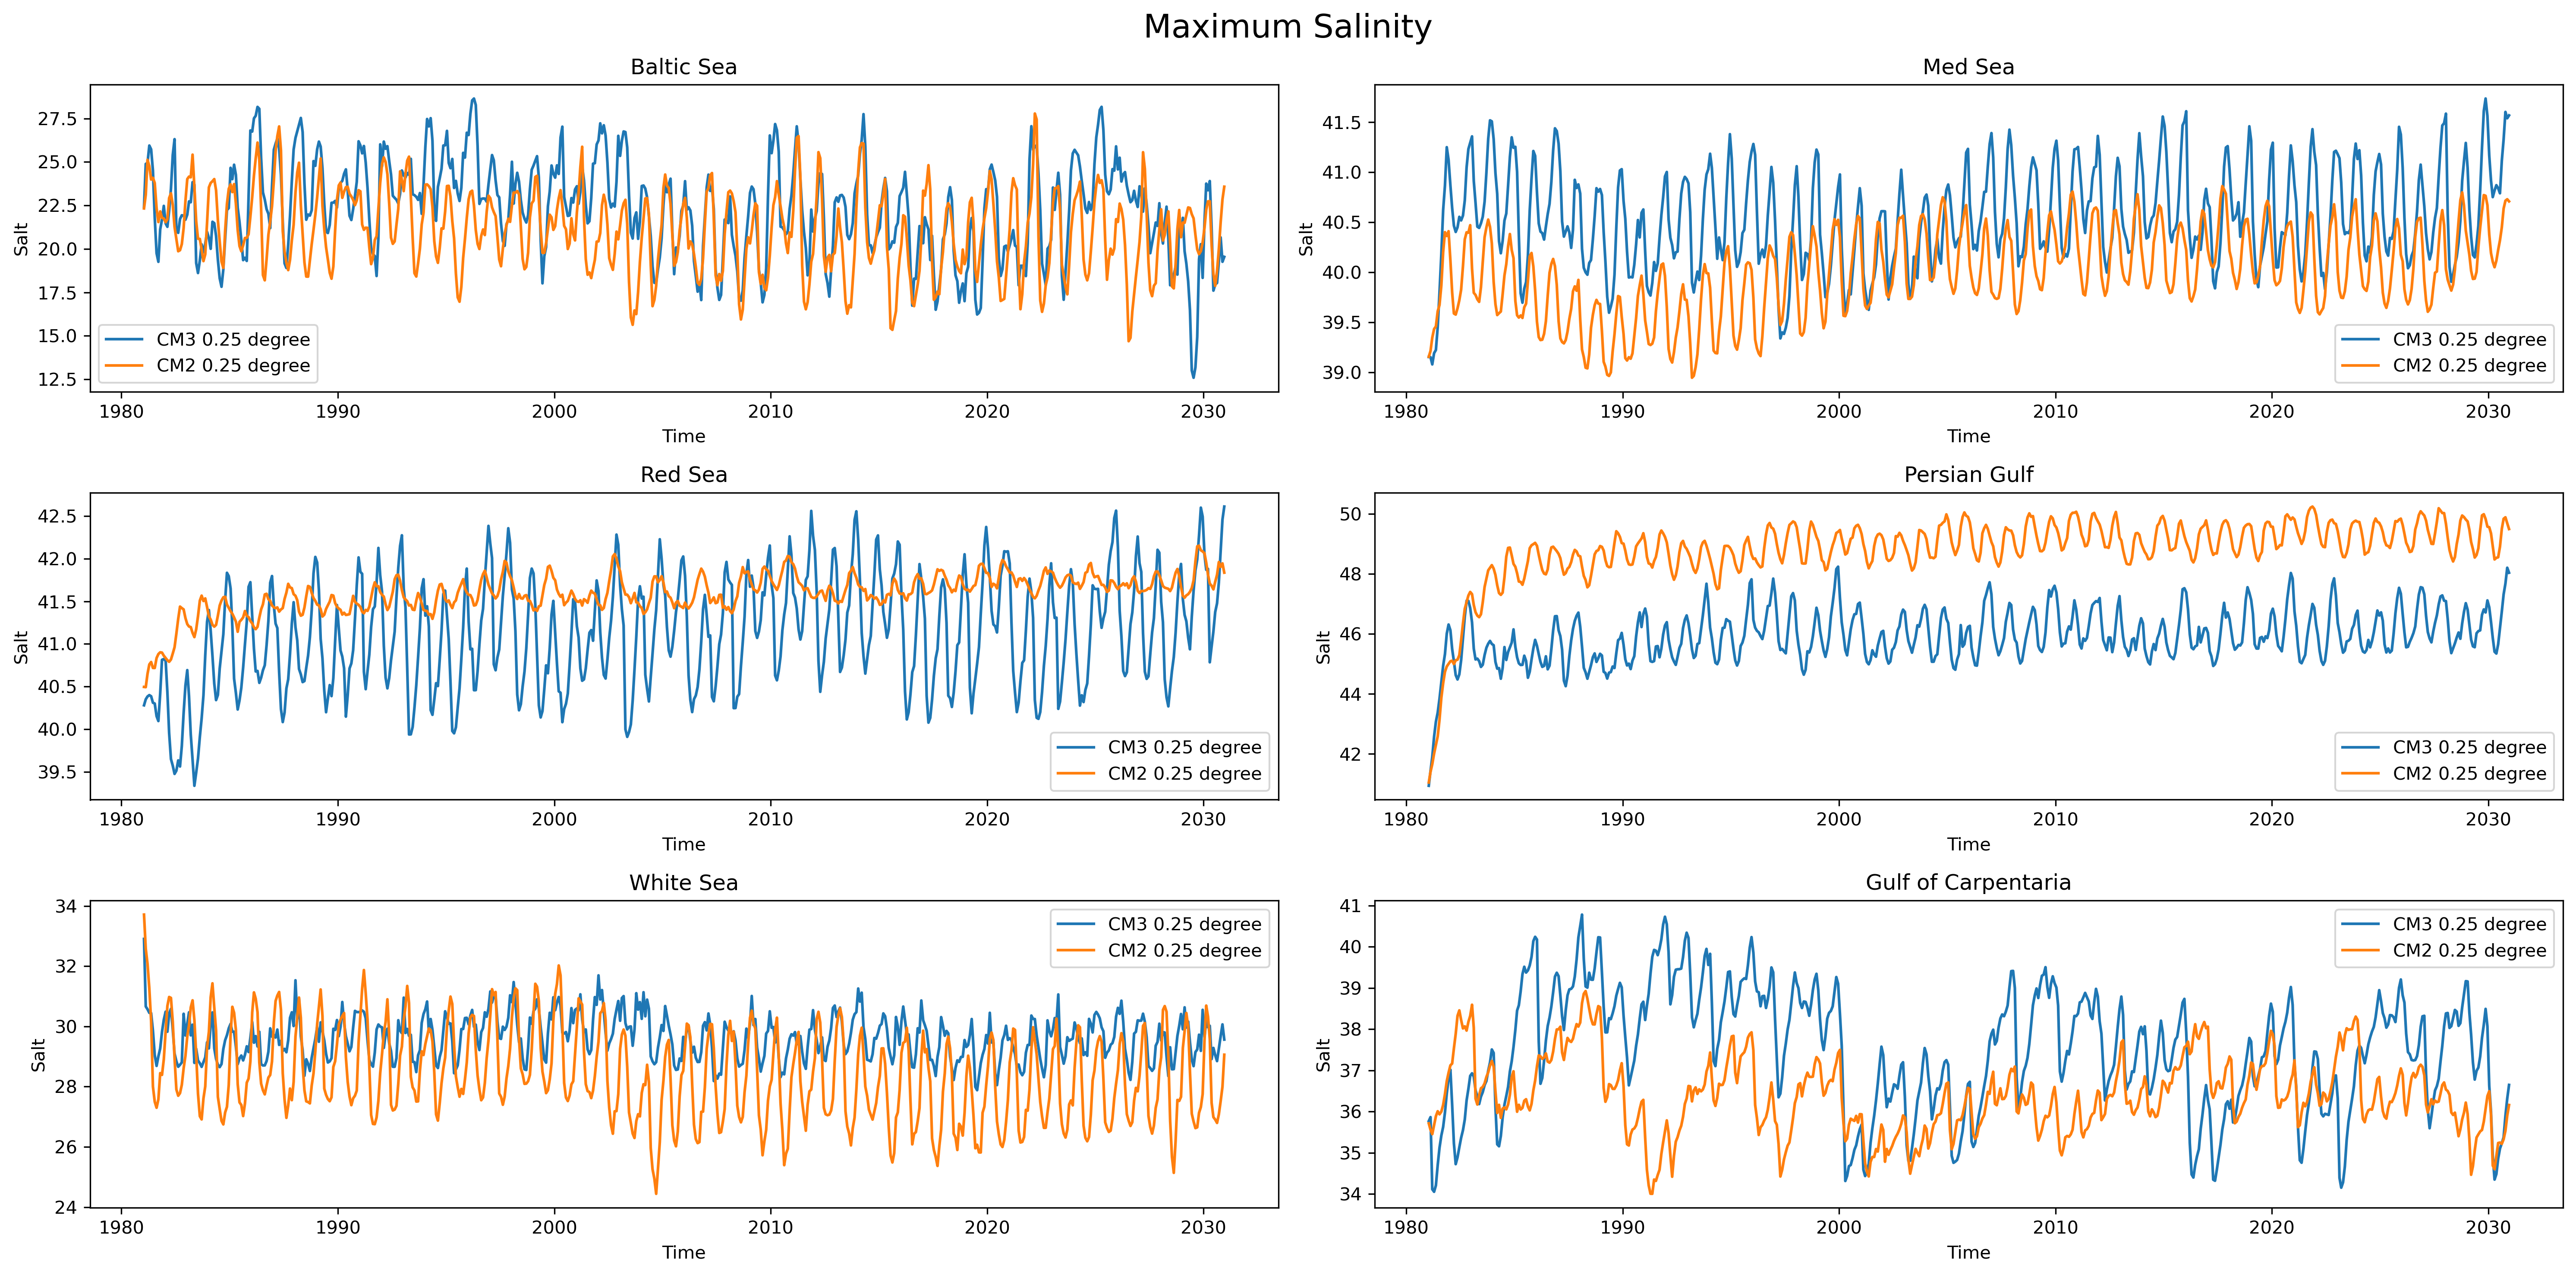

In [31]:
figsize = (20, 10)
num_plots = len(lon_lat_pairs_all["om3"])
ncols = 2
fig, axes = subplots_fig_ax(num_plots, ncols, figsize)

axes = axes.flatten()

for pair_idx, (lon, lat) in enumerate(lon_lat_pairs_all["om3"]):
    ax = axes[pair_idx]
    cm3_avg_sal = cm3_sss.sel(xh=slice(lon[0], lon[1]), yh=slice(lat[0], lat[1])).max(dim=("xh", "yh")).compute()
    cm3_avg_sal.plot(ax=ax, label='CM3 0.25 degree')

n_time = min(len(cm3_sss.time), len(cm3_sss.time))
time_ax = cm3_sss.time
for pair_idx, (lon, lat) in enumerate(lon_lat_pairs_all["om2"]):
    ax = axes[pair_idx]
    cm2_avg_sal = cm2_sss.sel(xh=slice(lon[0], lon[1]), yh=slice(lat[0], lat[1])).max(dim=("xh", "yh")).compute()
    ax.plot(time_ax[:n_time], cm2_avg_sal[:n_time], label='CM2 0.25 degree')

    ax.set_title(f"{seas[pair_idx]}")
    ax.set_xlabel("Time")
    ax.set_ylabel("Salt")
    ax.legend(loc="best")
        

for j in range(num_plots, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Maximum Salinity", fontsize=18)
plt.tight_layout()

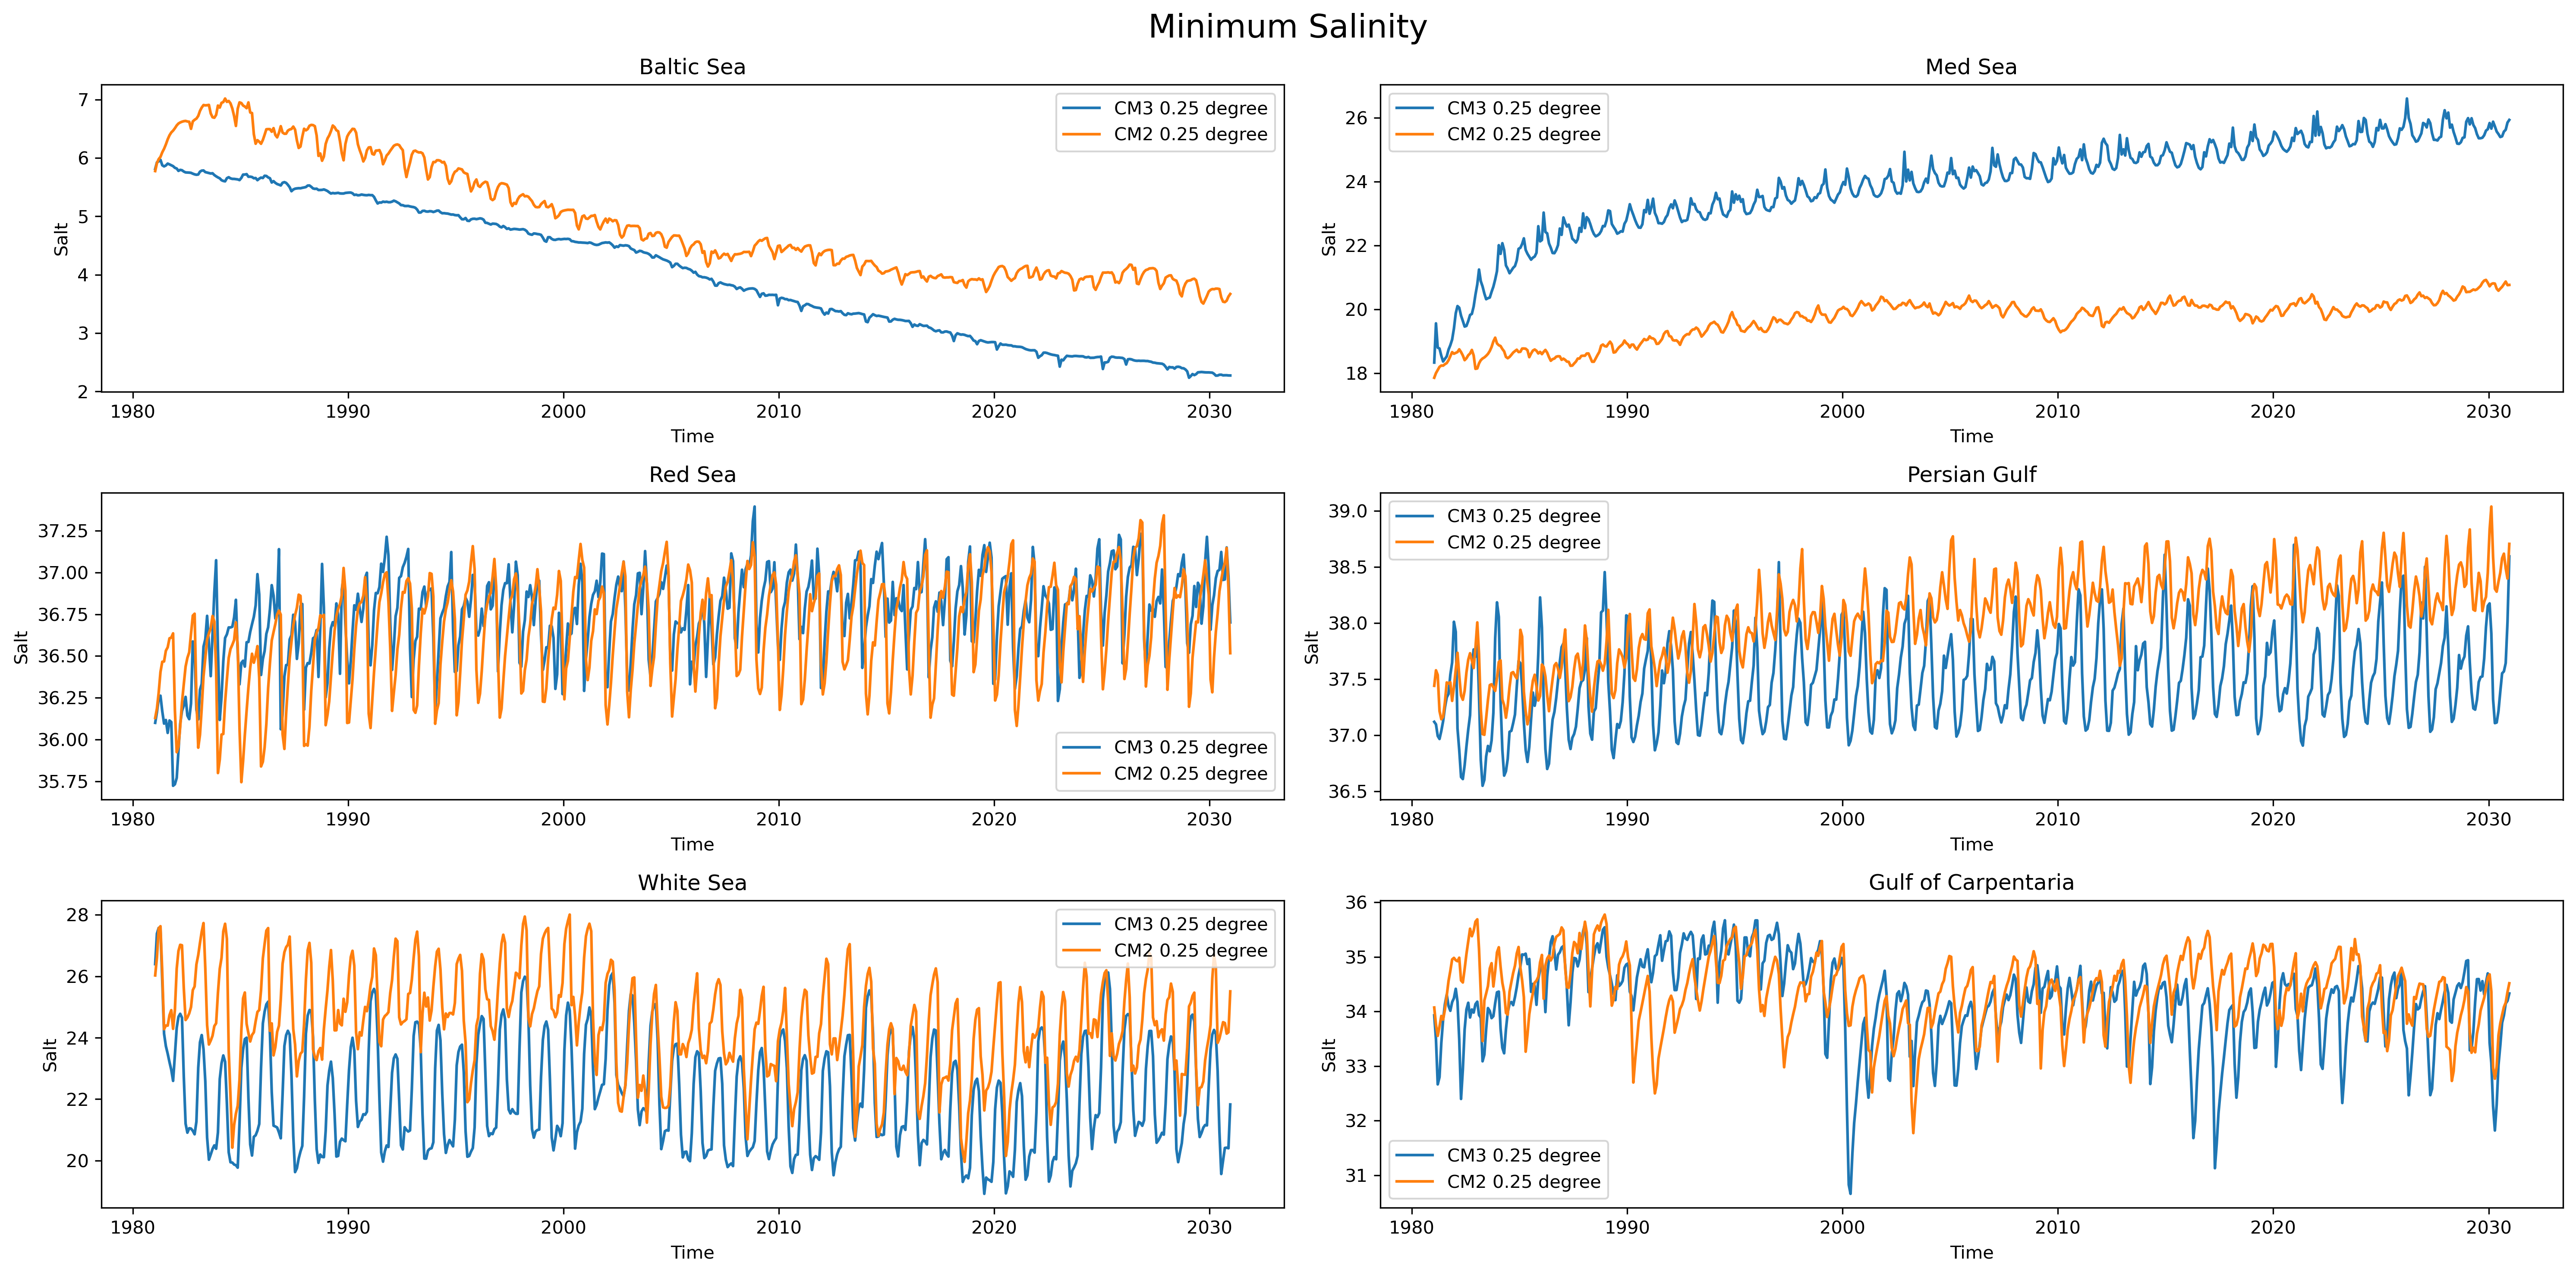

In [32]:
figsize = (20, 10)
num_plots = len(lon_lat_pairs_all["om3"])
ncols = 2
fig, axes = subplots_fig_ax(num_plots, ncols, figsize)

axes = axes.flatten()

for pair_idx, (lon, lat) in enumerate(lon_lat_pairs_all["om3"]):
    ax = axes[pair_idx]
    cm3_avg_sal = cm3_sss.sel(xh=slice(lon[0], lon[1]), yh=slice(lat[0], lat[1])).min(dim=("xh", "yh")).compute()
    cm3_avg_sal.plot(ax=ax, label='CM3 0.25 degree')


n_time = min(len(cm3_sss.time), len(cm3_sss.time))
time_ax = cm3_sss.time
for pair_idx, (lon, lat) in enumerate(lon_lat_pairs_all["om2"]):
    ax = axes[pair_idx]
    cm2_avg_sal = cm2_sss.sel(xh=slice(lon[0], lon[1]), yh=slice(lat[0], lat[1])).min(dim=("xh", "yh")).compute()
    ax.plot(time_ax[:n_time], cm2_avg_sal[:n_time], label='CM2 0.25 degree')

    ax.set_title(f"{seas[pair_idx]}")
    ax.set_xlabel("Time")
    ax.set_ylabel("Salt")
    ax.legend(loc="best")
        

for j in range(num_plots, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Minimum Salinity", fontsize=18)
plt.tight_layout()

## Plot basins

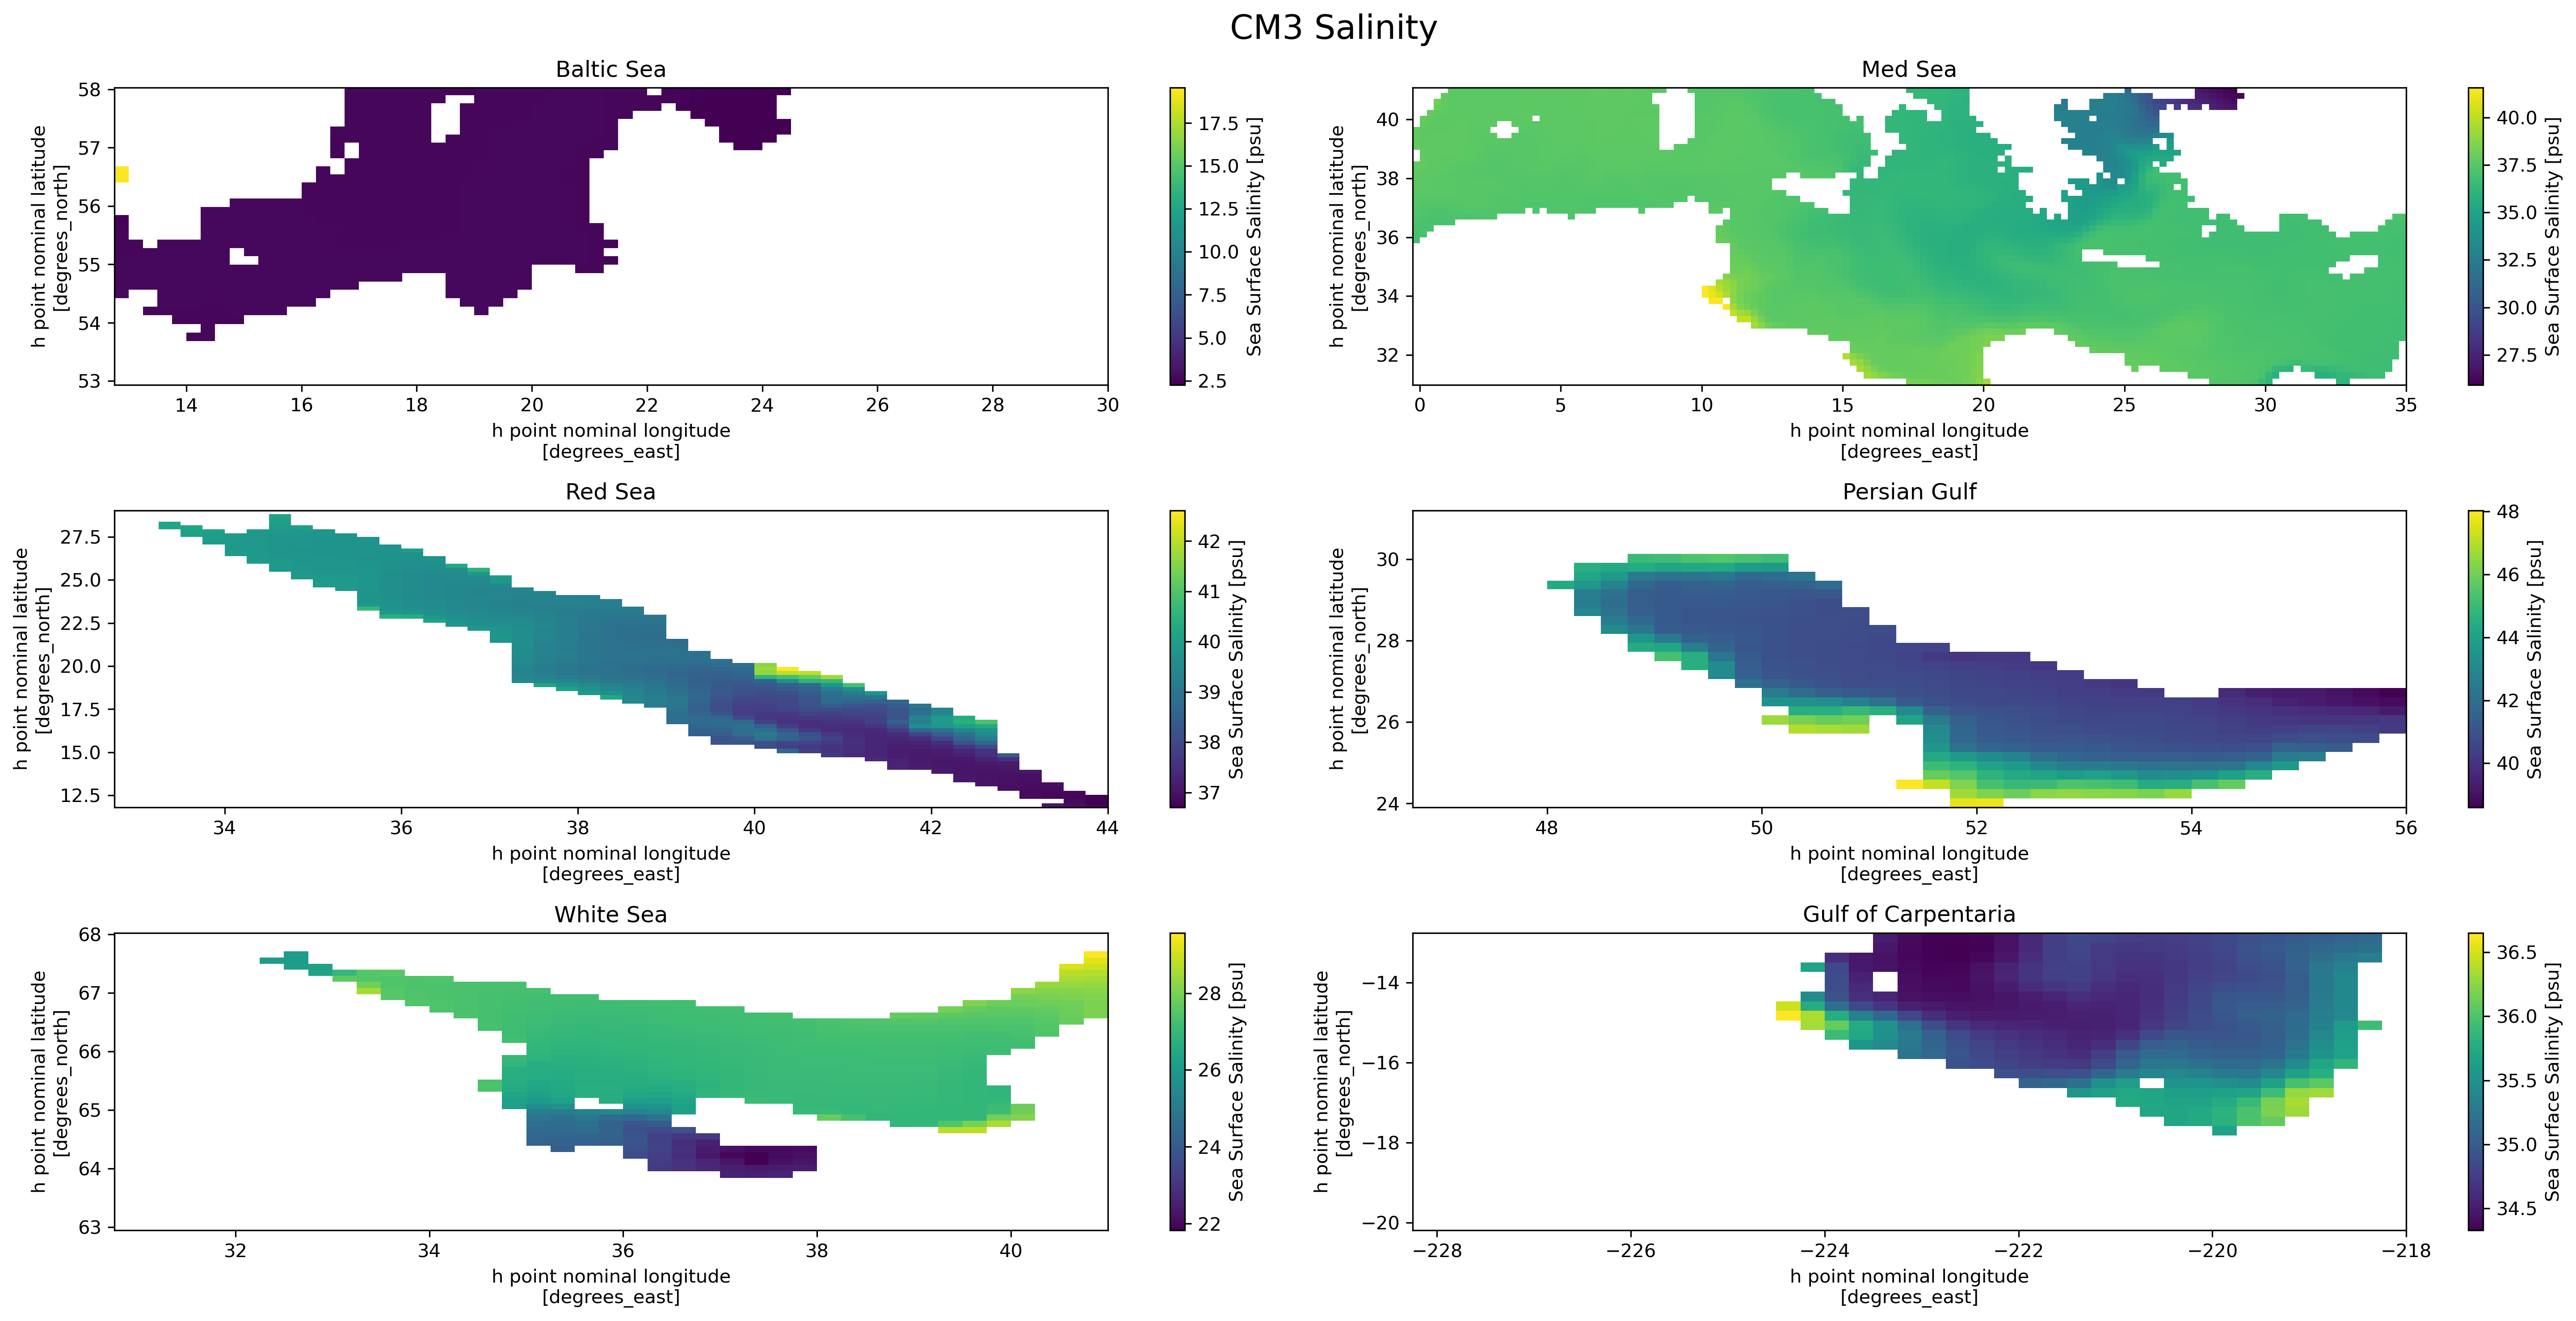

In [33]:
figsize = (20, 10)
num_plots = len(lon_lat_pairs_all["om3"])
ncols = 2
fig, axes = subplots_fig_ax(num_plots, ncols, figsize)

axes = axes.flatten()

cm3_sss_slice = cm3_sss.isel(time=12 * 50 - 1).compute()

for pair_idx, (lon, lat) in enumerate(lon_lat_pairs_all["om3"]):
    ax = axes[pair_idx]
    cm3_sss_slice.sel(xh=slice(lon[0], lon[1]), yh=slice(lat[0], lat[1])).plot(ax=ax)
    ax.set_title(f"{seas[pair_idx]}")


fig.suptitle("CM3 Salinity", fontsize=18)
plt.tight_layout()